In [ ]:
# Author: Alberto Fernández Comesaña

import pandas as pd
import os
import matplotlib.pyplot as plt
import torch

import utils
from sklearn.metrics import r2_score

In [2]:
DISCHARGES_DIR = os.path.join(os.pardir, 'discharges')
METEO_DIR = os.path.join(os.pardir, 'meteo-csv')

X_train, Y_train, X_test, Y_test = utils.load_data(METEO_DIR, DISCHARGES_DIR, 'B')

X_train = torch.tensor(X_train.values.astype(float), dtype=torch.float32)
X_test = torch.tensor(X_test.values.astype(float), dtype=torch.float32)
Y_train = torch.tensor(Y_train.values.astype(float), dtype=torch.float32)
Y_test = torch.tensor(Y_test.values.astype(float), dtype=torch.float32)

Epoch 1/2500 - TrainLoss: 2900.8652
Epoch 10/2500 - TrainLoss: 1492.8001
Epoch 20/2500 - TrainLoss: 1462.1781
Epoch 30/2500 - TrainLoss: 1428.2981
Epoch 40/2500 - TrainLoss: 1407.7116
Epoch 50/2500 - TrainLoss: 1397.1919
Epoch 60/2500 - TrainLoss: 1390.7650
Epoch 70/2500 - TrainLoss: 1386.3469
Epoch 80/2500 - TrainLoss: 1383.4845
Epoch 90/2500 - TrainLoss: 1381.3575
Epoch 100/2500 - TrainLoss: 1379.3866
Epoch 110/2500 - TrainLoss: 1377.4466
Epoch 120/2500 - TrainLoss: 1375.8608
Epoch 130/2500 - TrainLoss: 1374.3908
Epoch 140/2500 - TrainLoss: 1372.8766
Epoch 150/2500 - TrainLoss: 1371.4571
Epoch 160/2500 - TrainLoss: 1370.1218
Epoch 170/2500 - TrainLoss: 1368.8020
Epoch 180/2500 - TrainLoss: 1367.5905
Epoch 190/2500 - TrainLoss: 1366.3355
Epoch 200/2500 - TrainLoss: 1365.1801
Epoch 210/2500 - TrainLoss: 1364.0215
Epoch 220/2500 - TrainLoss: 1362.7988
Epoch 230/2500 - TrainLoss: 1361.7233
Epoch 240/2500 - TrainLoss: 1360.6408
Epoch 250/2500 - TrainLoss: 1359.5800
Epoch 260/2500 - TrainL

0.25824737548828125

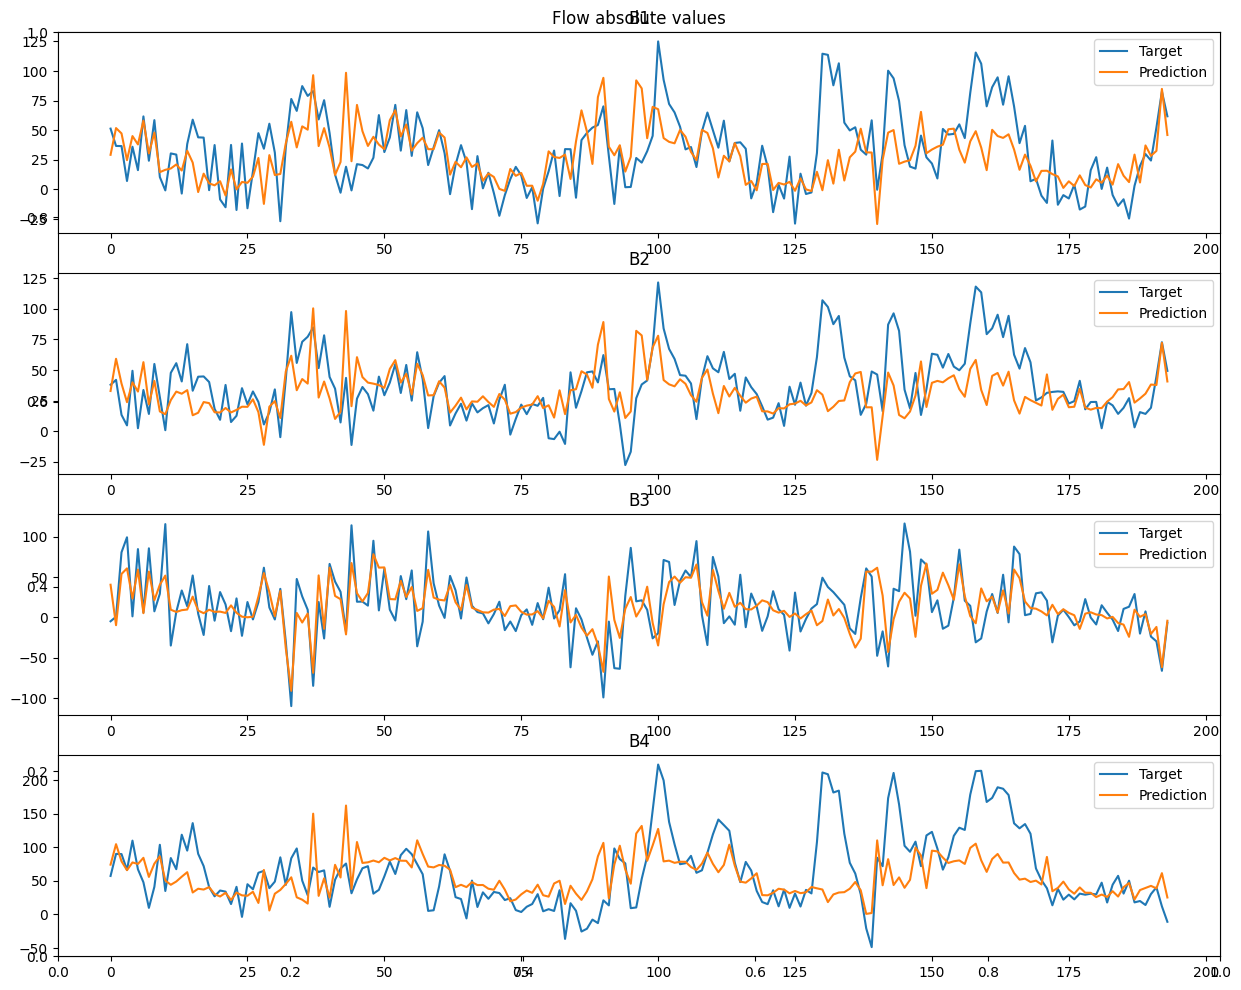

In [15]:
# ----------------------------------------------------
# Single Layer Perceptron with Linear output
# ----------------------------------------------------
class NeuralNetwork(torch.nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        
        self.model = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 50),
            torch.nn.ReLU(),
            torch.nn.Linear(50, 40),
            torch.nn.ReLU(),
            torch.nn.Linear(40, 30),
            torch.nn.ReLU(),
            torch.nn.Linear(30, 20),
            torch.nn.ReLU(),
            torch.nn.Linear(20, output_dim)
        )
        
    def forward(self, X):
        return self.model(X)

model = NeuralNetwork(input_dim=X_train.shape[1], output_dim=Y_train.shape[1])
loss_func = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)


# Train model
train_dataset = torch.utils.data.TensorDataset(X_train, Y_train)
train_loader  = torch.utils.data.DataLoader(train_dataset, batch_size = 10)

n_epochs = 2500

epoch_losses = []
test_losses = []

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, Y_batch in train_loader:
        output = model(X_batch)
        loss = loss_func(output, Y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        running_loss += loss.item() * X_batch.size(0)
    
    if (epoch+1) % 10 == 0 or epoch == 0:    
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_losses += [epoch_loss]
        print(f"Epoch {epoch+1}/{n_epochs} - TrainLoss: {epoch_loss:.4f}")
    
Y_pred = model(X_test).detach().numpy()

plt.figure(figsize=(15,12))
plt.title("Flow absolute values")
for fig_idx in range(1,5):
    plt.subplot(4,1,fig_idx)
    plt.title(f"B{fig_idx}")
    plt.plot(Y_test[:,fig_idx-1], label="Target")
    plt.plot(Y_pred[:,fig_idx-1], label="Prediction")
    plt.legend()
    
r2_score(Y_test, Y_pred)

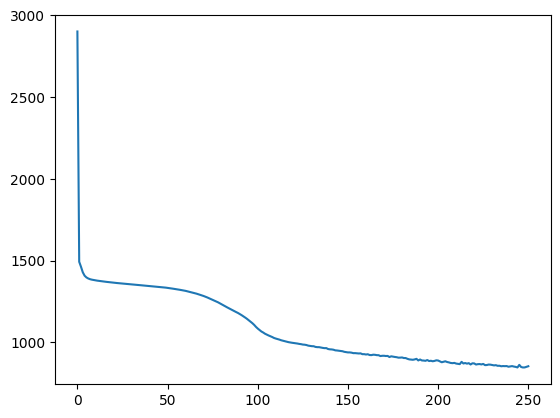

In [16]:
plt.plot(epoch_losses)